In [ ]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import ast
import seaborn as sns
from datasets import load_dataset

datas = load_dataset('lukebarousse/data_jobs')

df = datas['train'].to_pandas()
# df = pd.read_csv('../data_jobs.csv')

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skills: ast.literal_eval(skills) if pd.notna(skills) else skills)
countries = ['Denmark','Netherlands','Sweden','Norway','Belgium','Luxemburg','Ireland']
european_countries = [
    # Western Europe
    'Austria', 'Belgium', 'France', 'Germany', 'Liechtenstein', 
    'Luxembourg', 'Monaco', 'Netherlands', 'Switzerland',
    
    # Northern Europe & Nordics / Baltics
    'Denmark', 'Estonia', 'Finland', 'Iceland', 'Ireland', 
    'Latvia', 'Lithuania', 'Norway', 'Sweden', 'United Kingdom',
    
    # Southern Europe
    'Albania', 'Andorra', 'Bosnia and Herzegovina', 'Croatia', 'Cyprus', 
    'Gibraltar', 'Greece', 'Italy', 'Malta', 'Montenegro', 
    'North Macedonia', 'Portugal', 'San Marino', 'Serbia', 'Slovenia', 'Spain',
    
    # Eastern Europe
    'Belarus', 'Bulgaria', 'Czechia', 
    'Czech Republic', 'Georgia', 'Hungary', 
    'Poland', 'Romania', 'Slovakia'
]
jobs = sorted(['Data Engineer','Senior Data Engineer', 'Data Scientist'])
dfe = df[df["job_title_short"].isin(jobs)].copy()
dfe = dfe[dfe['job_country'].isin(countries)] #change this accordingly with countries of interest

In [3]:
dfex = dfe.explode('job_skills')
dfes = dfex.groupby(['job_skills','job_title_short']).size()
dfes = dfes.reset_index(name='skill_count')
dfes.sort_values(by='skill_count',ascending=False,inplace=True)
dfes.head(20)

,job_skills,job_title_short,skill_count
446,sql,Data Engineer,8600
356,python,Data Engineer,8580
31,azure,Data Engineer,6705
357,python,Data Scientist,6232
447,sql,Data Scientist,4067
28,aws,Data Engineer,4054
432,spark,Data Engineer,3179
368,r,Data Scientist,3092
90,databricks,Data Engineer,2751
197,java,Data Engineer,2102


In [4]:
dfj = dfe['job_title_short'].value_counts().reset_index(name='jobs_total')
dft = pd.merge(dfes,dfj,how='left',on='job_title_short')

dft['skills_percentage'] = dft['skill_count'] / dft['jobs_total']
dft[['skill_count','jobs_total']].head(20)
dft[dft['job_title_short'] == 'Data Engineer'].head(20)

,job_skills,job_title_short,skill_count,jobs_total,skills_percentage
0,sql,Data Engineer,8600,15507,0.554588
1,python,Data Engineer,8580,15507,0.553299
2,azure,Data Engineer,6705,15507,0.432385
5,aws,Data Engineer,4054,15507,0.261430
6,spark,Data Engineer,3179,15507,0.205004
8,databricks,Data Engineer,2751,15507,0.177404
9,java,Data Engineer,2102,15507,0.135552
10,kafka,Data Engineer,2005,15507,0.129296
11,power bi,Data Engineer,1959,15507,0.126330
15,scala,Data Engineer,1678,15507,0.108209


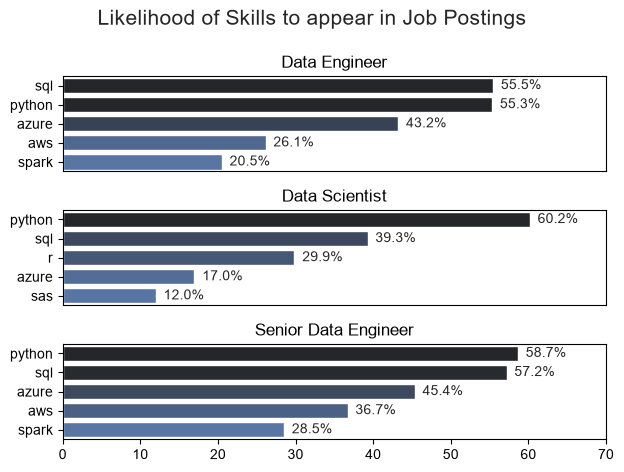

In [ ]:
fig,ax = plt.subplots(len(jobs),1)
sns.set_theme(style='ticks')
for i,job in enumerate(jobs):
    dfp = dft[dft['job_title_short'] == job].head(5)
    sns.barplot(data=dfp,x='skills_percentage',y='job_skills', ax=ax[i], hue='skill_count',palette='dark:b_r')
    ax[i].set_title(job)
    ax[i].set_xlabel('')
    ax[i].legend().set_visible(False)
    ax[i].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos:f'{int(x*100)}'))
    ax[i].set_ylabel('')
    ax[i].set_xlim(0,0.70)
    if i != len(jobs) - 1: ax[i].set_xticks([])
    for n,v in enumerate(dfp['skills_percentage']):
        ax[i].text(v + .01 ,n,f'{v*100:.1f}%', va='center',fontsize=10)
fig.suptitle('Likelihood of Skills to appear in Job Postings',fontsize=15)
fig.tight_layout()